# Parts 2–3 walkthrough — reference, simulation, Longstaff–Schwartz

| module | role |
|---|---|
| `reference.py` | single entry point for the reference (**placeholder = our solver at $m=20$** until the supplied npz arrives) |
| `part2_reference_check.py` | refinement study (spatial / time / domain) vs changing $N$ |
| `simulation.py` | exact paths, training mixture $A$, seeded path sets (**assumed draw order**) |
| `lsm.py` | LS regression → threshold → cap, replay check |
| `evaluate.py` | frozen-policy prices, boundary errors, ordering diagnostics |

In [1]:
import numpy as np, pandas as pd
pd.set_option("display.width", 160)
import config as cfg, simulation as sim, lsm, evaluate as ev, part2_reference_check as p2
from reference import load_reference
from IPython.display import Image

## Step 1 — How precise is the reference?

**Design.** Change one numerical setting at a time and record the largest price change and the largest boundary change. The same table shows the effect of going from $N=180$ to $360$, which is a different problem rather than a refinement.

In [2]:
display(p2.refinement_table()[["N","delta","refinement","dV_spots","db"]])
display(p2.n_change_table())

,N,delta,refinement,dV_spots,db
0,180,0.0000,spatial dx/2,1.051821e-05,1.079353e-03
1,180,0.0000,spatial dx/4,1.328388e-05,1.020396e-03
2,180,0.0000,time h/2 (substeps=2),1.207647e-09,1.419807e-07
3,180,0.0000,time h/4 (substeps=4),3.462635e-09,4.259877e-07
4,180,0.0000,domain wider,0.000000e+00,0.000000e+00
5,180,0.0000,kernel tails n_sd=14,0.000000e+00,2.984279e-13
6,180,0.0125,spatial dx/2,1.195648e-05,1.079353e-03
7,180,0.0125,spatial dx/4,1.524521e-05,1.020396e-03
8,180,0.0125,time h/2 (substeps=2),9.750867e-10,1.419807e-07
9,180,0.0125,time h/4 (substeps=4),2.708518e-09,4.259877e-07


,delta,dV(60),dV(80),dV(100),min_dV_grid,max_db,mean_db
0,0.0000,0.0,0.002195,0.001298,0.0,0.305174,-0.256222
1,0.0125,0.0,0.000655,0.000557,0.0,0.305174,-0.078399


**Reading.**
* Time refinement is essentially zero, because the kernel integrates the lognormal step exactly.
* Spatial refinement changes prices by about $10^{-5}$ \$ and boundaries by about $10^{-3}$ \$.
* Changing $N$ changes prices by about $10^{-3}$ \$ and boundaries by about $0.3$ \$.
* So any accuracy claim smaller than about $10^{-5}$ \$ cannot be resolved against this reference.

## Step 2 — Exact simulation and the martingale check

Under $Q$, $E[S_T]=S_0e^{rT}(1-\delta)^3$. We check it on the final $S_0=100$ evaluation sample and report $z$ = (difference)/SE.

In [3]:
display(pd.DataFrame([sim.martingale_check(c) for c in range(4)]))
rng = np.random.default_rng(0); A = sim.sample_A(rng, 200_000) / cfg.K
print("P(A/K < 0.2) =", (A < 0.2).mean(), " theory:", 0.5*np.log(200)/np.log(1000))

,case,N,delta,mean_ST,theory,diff,se,z
0,0,180,0.0000,103.741356,103.727037,0.014318,0.122044,0.117320
1,1,180,0.0125,99.959089,99.885693,0.073396,0.117701,0.623577
2,2,360,0.0000,103.967531,103.727037,0.240494,0.122395,1.964898
3,3,360,0.0125,99.912295,99.885693,0.026602,0.117849,0.225726


P(A/K < 0.2) = 0.38505  theory: 0.38350499927733017


## Step 3 — Fit LS on each case

**Checks.**
* The fallback, multiple-crossing and capped-date counts.
* The **replay** check: forward application of the frozen rule must reproduce the backward targets exactly.

In [4]:
ls = {}
for c in range(4):
    tg, S = sim.training_paths_LS(c)
    ls[c] = lsm.fit_ls(S, tg, sim.CASES[c][1])
    r = ls[c]
    print(c, sim.CASES[c], "fallbacks", len(r.fallback), "| multi-crossing", len(r.multi_cross_dates),
          "| capped", len(r.capped_dates), "| replay max|Q-Y|", r.replay_max_abs_diff)

0 (180, 0.0) fallbacks 0 | multi-crossing 179 | capped 0 | replay max|Q-Y| 0.0


1 (180, 0.0125) fallbacks 0 | multi-crossing 142 | capped 85 | replay max|Q-Y| 0.0


2 (360, 0.0) fallbacks 0 | multi-crossing 360 | capped 0 | replay max|Q-Y| 0.0


3 (360, 0.0125) fallbacks 0 | multi-crossing 264 | capped 149 | replay max|Q-Y| 0.0


## Step 4 — Why two crossings?

The cubic is fitted over $x\in[0.001,1]$. As a result, $H$ dips below zero near $s\approx3$ and turns positive again before the true boundary. The largest-crossing rule keeps the economically correct single exercise interval.

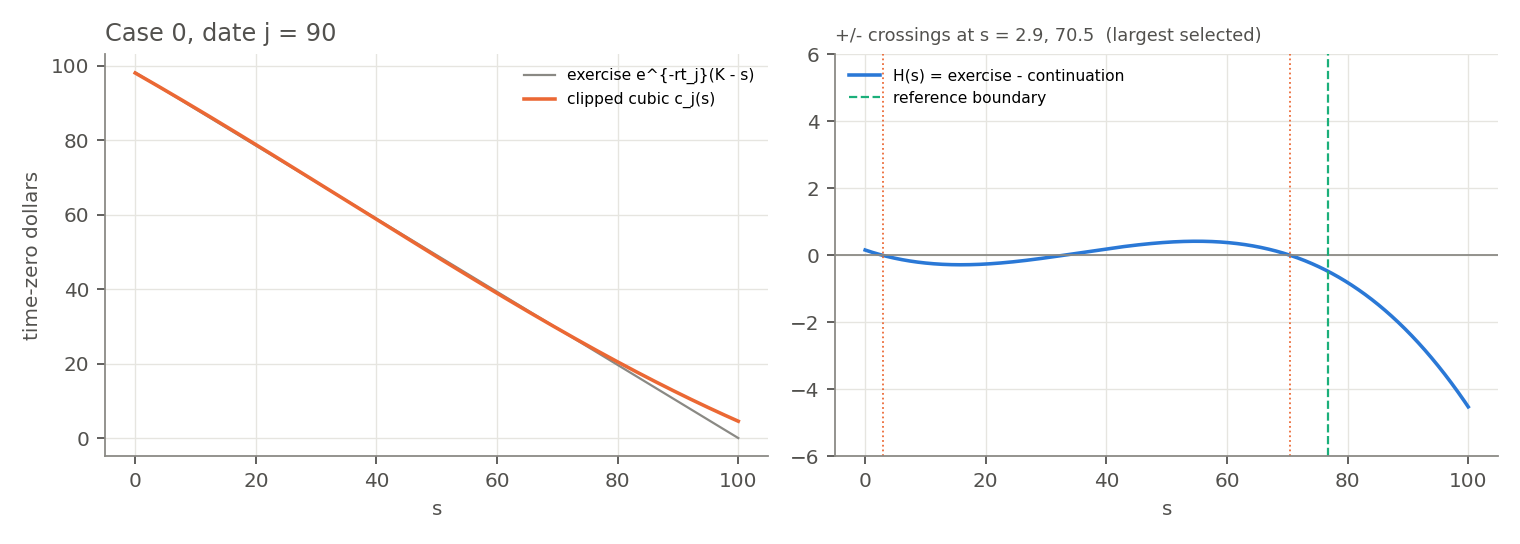

In [5]:
Image("figures/p23_H_example.png")

## Step 5 — Boundaries and prices (Part 5 preview for LS)

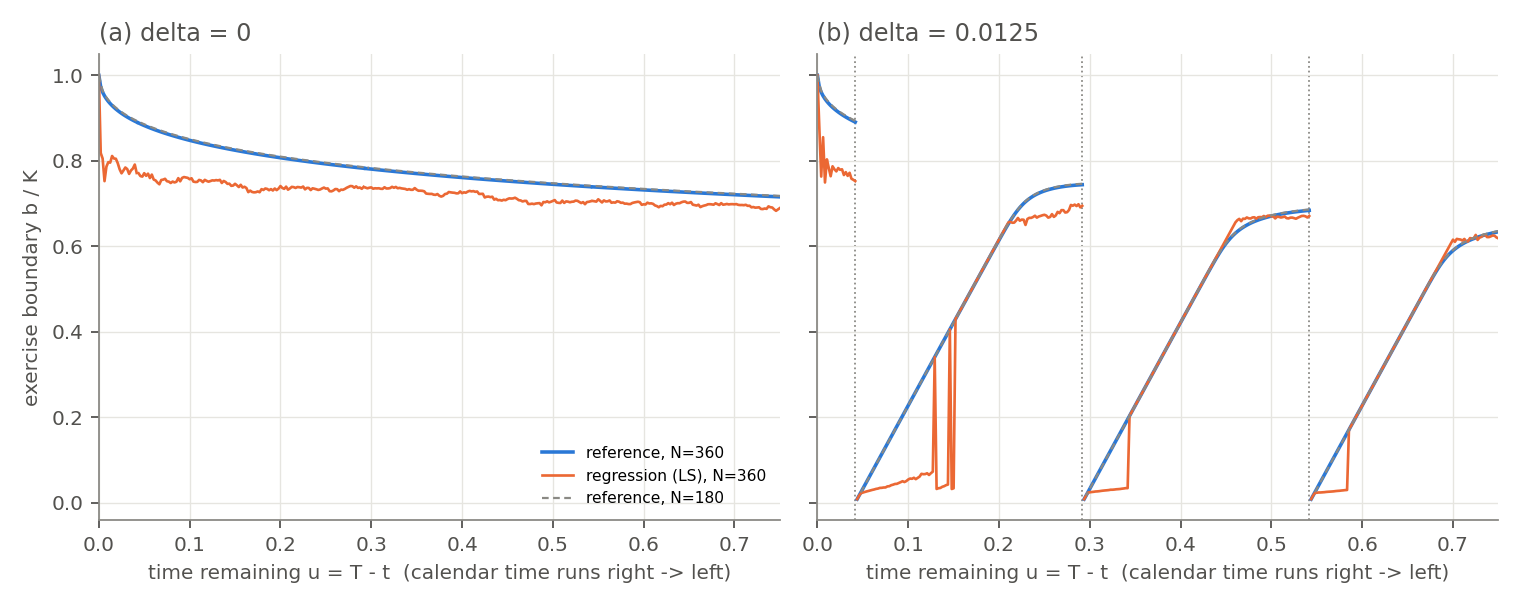

In [6]:
Image("figures/p23_boundaries_ls_ref.png")

In [7]:
display(pd.read_csv("tables/p5_prices_preview.csv"))
display(pd.read_csv("tables/p5_paired_preview.csv"))
display(pd.read_csv("tables/p5_boundary_errors_preview.csv"))
display(pd.read_csv("tables/p1_ordering_checks.csv"))

,case,N,delta,method,S0,mean,se,lo,hi,ref_value
0,0,180,0.0000,LS,60.0,40.000000,3.177675e-17,40.000000,40.000000,39.999998
1,0,180,0.0000,ref-boundary policy,60.0,40.000000,3.177675e-17,40.000000,40.000000,39.999998
2,0,180,0.0000,LS,80.0,20.652573,5.608711e-02,20.542642,20.762503,20.868801
3,0,180,0.0000,ref-boundary policy,80.0,20.843424,4.474407e-02,20.755726,20.931123,20.868801
4,0,180,0.0000,LS,100.0,8.648361,4.971050e-02,8.550928,8.745793,8.807848
5,0,180,0.0000,ref-boundary policy,100.0,8.773276,4.475932e-02,8.685548,8.861004,8.807848
6,1,180,0.0125,LS,60.0,40.000000,3.177675e-17,40.000000,40.000000,39.999998
7,1,180,0.0125,ref-boundary policy,60.0,40.000000,3.177675e-17,40.000000,40.000000,39.999998
8,1,180,0.0125,LS,80.0,21.997131,6.301924e-02,21.873613,22.120649,22.109547
9,1,180,0.0125,ref-boundary policy,80.0,22.041170,5.942868e-02,21.924690,22.157650,22.109547


,case,pair,S0,mean_diff,se
0,0,LS - ref-boundary policy,60.0,0.000000,0.000000
1,0,LS - ref-boundary policy,80.0,-0.190852,0.034324
2,0,LS - ref-boundary policy,100.0,-0.124915,0.022751
3,1,LS - ref-boundary policy,60.0,0.000000,0.000000
4,1,LS - ref-boundary policy,80.0,-0.044039,0.021149
5,1,LS - ref-boundary policy,100.0,-0.057487,0.014848
6,2,LS - ref-boundary policy,60.0,0.000000,0.000000
7,2,LS - ref-boundary policy,80.0,-0.188776,0.030124
8,2,LS - ref-boundary policy,100.0,-0.102873,0.021542
9,3,LS - ref-boundary policy,60.0,0.000000,0.000000


,case,N,delta,method,E_mean,E_max,j_at_max
0,0,180,0.0000,LS,0.065132,0.164848,179
1,1,180,0.0125,LS,0.032329,0.234600,152
2,2,360,0.0000,LS,0.055484,0.199469,357
3,3,360,0.0125,LS,0.046729,0.387941,288


,N,method,A,B,F
0,180,ref,0.0,0.0,0.000000
1,180,LS,0.0,0.0,0.200384
2,180,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
3,360,ref,0.0,0.0,0.000000
4,360,LS,0.0,0.0,0.102824
5,360,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000


**Reading.**
* LS boundary errors are several percent of $K$, yet the price loss is only 0.02–0.19 \$. The value is flat near the optimal threshold, so price error is roughly second order in boundary error.
* LS respects the ordering before $d_3$ ($A=0$). The nonzero $F$ after $d_3$ is regression and sampling noise between two independently trained fits.